# Effective diffusivity of a random suspension of impermeable disks

This example combines the `pymrm` immersed boundary method with a **Monte-Carlo**
placement of many non-overlapping circular particles and a **grid-convergence study** of
a derived engineering quantity: the *effective diffusion coefficient* of the porous
medium formed by the fluid around the impermeable particles.

The physical model is exactly the impermeable-particle case of the
`ibm_touching_particles` example -- at every particle surface a
**homogeneous Neumann** condition $\partial c/\partial n = 0$ is imposed on the fluid
side (no diffusion into the solid), and the solid interior is pinned by a **zero
Dirichlet** value.  Steady diffusion is driven across the domain by $c=1$ at the inlet
(left) and $c=0$ at the outlet (right), with no-flux top/bottom walls.

We

1. place `n_particles` disks at random -- non-overlapping with each other, clear of the
   side walls, and at least one coarse grid cell from inlet and outlet;
2. size the disks so that at the **coarsest** grid the diameter is resolved by 5 cells
   (`diameter / h = 5`);
3. solve the impermeable-particle diffusion problem and evaluate the effective
   diffusivity $D_\mathrm{eff}$ from the through-flux;
4. **refine the same physical geometry** on successively finer grids and watch
   $D_\mathrm{eff}$ converge.

In [1]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from scipy.sparse import eye_array
from scipy.sparse.linalg import spsolve
from scipy.ndimage import label

from pymrm import (
    construct_grad, construct_div,
    apply_ibm, apply_ibm_vector, construct_ibm_particles, Circle as Disk,
    construct_ibm_normal_derivative, construct_ibm_boundary_values,
)

# --- Physical parameters (grid-independent) ---
L = 1.0                     # square domain size
D = 1.0                     # diffusion coefficient of the liquid
N_coarse = 40               # coarsest grid: diameter spans 5 cells
R = 3.0 / N_coarse          # disk radius  ->  diameter = 5 * (L / N_coarse)
h_coarse = L / N_coarse
n_particles = 18

# Placement clearances, measured in *coarse* grid cells:
gap_cells = 0.0             # min liquid gap between two particles
wall_cells = 2.0            # min clearance from every inlet and outlet wall

print(f'disk radius R          : {R:.4f}  (diameter = {2 * R / h_coarse:.0f} coarse cells)')
print(f'coarse cell size h     : {h_coarse:.4f}')

disk radius R          : 0.0750  (diameter = 6 coarse cells)
coarse cell size h     : 0.0250


## Monte-Carlo placement

A simple rejection sampler draws candidate centres uniformly in the admissible box and
keeps a candidate only if it clears every previously accepted disk by at least
`gap_cells` coarse cells (here `gap_cells = 0`, so disks may just touch):

* **inlet / outlet (left, right):** the disk edge stays at least `wall_cells` coarse
  cells from $x=0$ and $x=L$, keeping the Dirichlet boundary columns clean;
* **side walls (top, bottom):** the disk may reach right up to -- and touch -- the
  no-flux walls; the immersed boundary handles cut cells in the outermost cell layer
  with a first-order reconstruction.

The centres are generated **once**, in physical coordinates, and reused unchanged on
every grid -- this is what makes the later grid-convergence study meaningful.  Letting
particles touch each other and the walls can, on a coarse grid, pinch off small enclosed
fluid pockets; these are dealt with in the solver (next section).

placed 18 particles
solid area fraction phi : 0.318


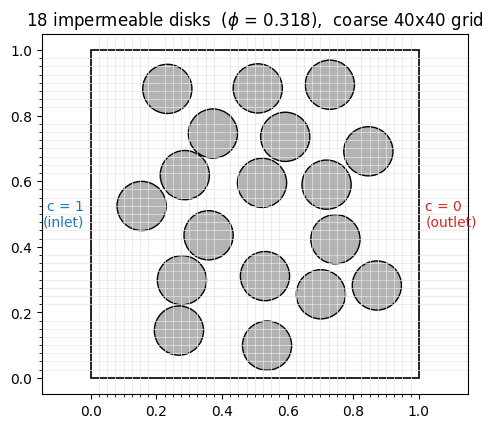

In [2]:
def place_particles(seed=1):
    """Rejection-sample non-overlapping disk centres in physical coordinates."""
    rng = np.random.default_rng(seed)
    gap = gap_cells * h_coarse
    lo_x = R + wall_cells * h_coarse
    hi_x = L - R - wall_cells * h_coarse
    lo_y = R
    hi_y = L - R
    centers = []
    for _ in range(200000):
        if len(centers) == n_particles:
            break
        p = np.array([rng.uniform(lo_x, hi_x), rng.uniform(lo_y, hi_y)])
        if all(np.hypot(*(p - q)) >= 2 * R + gap for q in centers):
            centers.append(p)
    if len(centers) < n_particles:
        raise RuntimeError(f'placed only {len(centers)} / {n_particles} particles')
    return np.array(centers)


centers = place_particles(seed=1)
area_fraction = n_particles * np.pi * R**2 / L**2
print(f'placed {len(centers)} particles')
print(f'solid area fraction phi : {area_fraction:.3f}')

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.add_patch(Rectangle((0, 0), L, L, fill=False, lw=1.2))
for cx, cy in centers:
    ax.add_patch(Circle((cx, cy), R, facecolor='0.7', edgecolor='k', lw=1.0))
ax.set_xticks(np.linspace(0, L, N_coarse + 1), minor=True)
ax.set_yticks(np.linspace(0, L, N_coarse + 1), minor=True)
ax.grid(which='minor', color='0.9', lw=0.5)
ax.annotate('c = 1\n(inlet)', (-0.02, 0.5), ha='right', va='center', color='tab:blue')
ax.annotate('c = 0\n(outlet)', (1.02, 0.5), ha='left', va='center', color='tab:red')
ax.set_xlim(-0.15, 1.15); ax.set_ylim(-0.05, 1.05)
ax.set_aspect('equal')
ax.set_title(f'{n_particles} impermeable disks  ($\\phi$ = {area_fraction:.3f}),  '
             f'coarse {N_coarse}x{N_coarse} grid')
plt.show()

## Solver and the effective diffusivity

For a given grid resolution `N` the solver:

* describes the disks as `Circle` particles and builds the immersed-boundary data with
  `construct_ibm_particles` (exact wall positions and normals; `contact='merge'` so
  touching disks stay connected), taking the sign-correct classification field from
  `info.pseudo_sdf`;
* assembles the bare Laplacian with the domain BCs and scales it by $-D$;
* applies the **homogeneous Neumann** condition on the fluid side of every crossing via
  `construct_ibm_boundary_values` (`{'a': 1, 'b': 0, 'd': 0}` $\Rightarrow$
  $\partial c/\partial n = 0$) and pins the solid interior to the **zero Dirichlet**
  value (`values_inside = 0`, so its `G_in` contribution vanishes);
* solves the steady system and integrates the boundary flux.

**Effective diffusivity.**  In steady state the total molar throughput is
$Q = \int_0^H J\,\mathrm dy$ with $J = -D\,\partial c/\partial x$ the local flux.  The
effective diffusivity follows from Fick's law applied to the homogenised slab,

$$D_\mathrm{eff} = \frac{\bar J}{\Delta c / L}
= \frac{Q\,L}{H\,\Delta c},\qquad \bar J = \frac{Q}{H},$$

i.e. the average flux divided by the imposed concentration gradient $\Delta c / L$.  Here
$H = L = 1$ and $\Delta c = 1$, so numerically $D_\mathrm{eff}$ equals the throughput
$Q$; dividing by the fluid $D$ gives the dimensionless obstruction factor
$D_\mathrm{eff}/D \le 1$.  Because the particles are impermeable and the fluid is
source-free, the inflow and outflow throughputs must agree; their mismatch is a useful
discretisation diagnostic that vanishes under refinement.

### Enclosed fluid pockets and the singular matrix

Because the particles may now touch each other and the top/bottom walls, a coarse grid
can **pinch off individual fluid cells** that end up surrounded by solid (and no-flux
walls) on every face.  Such a cell only ever sees homogeneous Neumann conditions, so
nothing fixes its concentration: its steady-state matrix row is identically zero and the
system is **singular** (`spsolve` returns `nan` with a *"matrix is exactly singular"*
warning).

A clean, physical remedy is to solve a **transient** step instead of the pure steady
problem.  We add the accumulation term $\partial c/\partial t$ (mass matrix
$\mathsf M = \mathsf I/\Delta t$), initialise $c=0$ everywhere, and take a **single
implicit-Euler step with a very large $\Delta t$**:

$$\Big(\tfrac{1}{\Delta t}\mathsf I - D\,\mathrm{div}\,\mathrm{grad}\Big)\,c^{1}
= \tfrac{1}{\Delta t}\,c^{0} - g_\mathrm{bc},\qquad c^{0}=0 .$$

The mass term places $1/\Delta t$ on **every** diagonal, so the matrix is nonsingular
everywhere.  On cells connected to the inlet/outlet, $\Delta t\to\infty$ recovers the
steady solution (the departure is $O(1/\Delta t)$).  An enclosed pocket has no flux
across any face, so it cannot change from its initial value and simply **stays at
$c=0$** -- the same harmless value we would otherwise have to pin by hand.  With
$\Delta t = 10^{8}$ (against the diffusion time $L^2/D = 1$) the connected region is at
steady state to $\sim 10^{-9}$.  The `iso` column below counts the enclosed cells the
accumulation term silently regularises.

In [3]:
def disconnected_liquid(fluid):
    """Liquid cells with no connected path to the inlet or outlet columns.

    Uses 4-connectivity (matching the finite-volume face stencil).  A liquid
    component that never reaches the x = 0 (inlet) or x = L (outlet) column is an
    enclosed no-flux pocket.  Reported only as a diagnostic ("iso" in the table);
    the accumulation term is what keeps such cells well-defined.
    """
    labels, _ = label(fluid)
    live = set(labels[0, :]) | set(labels[-1, :])     # components touching inlet/outlet
    live.discard(0)
    return fluid & ~np.isin(labels, list(live))


def solve_diffusion(centers, N, dt=1e8):
    """Solve the impermeable-particle problem on an N x N grid; return diagnostics.

    Regularised by one implicit-Euler step of the *transient* diffusion equation
    from ``c = 0`` with a very large ``dt``: the accumulation term ``I/dt`` makes
    every row nonsingular, while ``dt -> inf`` recovers the steady state on the
    connected liquid (enclosed pockets stay at their initial value 0).
    """
    x_f = [np.linspace(0.0, L, N + 1), np.linspace(0.0, L, N + 1)]
    x_c = [0.5 * (xf[:-1] + xf[1:]) for xf in x_f]
    X, Y = np.meshgrid(x_c[0], x_c[1], indexing='ij')
    shape = (N, N)
    n = N * N

    particles = [Disk((cx, cy), R) for cx, cy in centers]

    bc_x = ({'a': 0, 'b': 1, 'd': 1.0}, {'a': 0, 'b': 1, 'd': 0.0})   # inlet/outlet
    bc_y = ({'a': 1, 'b': 0, 'd': 0.0}, {'a': 1, 'b': 0, 'd': 0.0})   # no-flux sides

    Lap = None
    g_lap = np.zeros(n)
    for axis, bc in enumerate((bc_x, bc_y)):
        grad, grad_bc = construct_grad(shape, x_f[axis], x_c[axis], bc=bc, axis=axis)
        div = construct_div(shape, x_f[axis], axis=axis)
        term = (div @ grad).tocsr()
        Lap = term if Lap is None else Lap + term
        g_lap += (div @ grad_bc).toarray().ravel()

    # Transient operator  M - D div(grad),  with accumulation mass matrix M = I/dt
    M = eye_array(n, format='csr') / dt
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')            # coarse grids fall back to low order
        ibm, info = construct_ibm_particles(particles, x_c, contact='merge')
        sdf = info.pseudo_sdf                   # sign-correct union field
        fluid = sdf >= 0
        recon = construct_ibm_normal_derivative(ibm, sdf, x_c, length_scale=R,
                                             normals=info.normals)
        A_ibm, G_out, G_in = apply_ibm((M - D * Lap).tocsr(), ibm, return_bc='matrix')
        # liquid side: 1 * q_out + 0 * c_wall = 0  ->  homogeneous Neumann
        H_op, h_op = construct_ibm_boundary_values(
            ibm, recon, {'a': 1.0, 'b': 0.0, 'd': 0.0}, side='out')

    A = (A_ibm + G_out @ H_op).tocsr()
    # solid interior: zero Dirichlet  ->  values_inside = 0  ->  G_in term vanishes
    c_old = np.zeros(n)                             # initial condition c = 0
    g = (apply_ibm_vector(-D * g_lap - M @ c_old, ibm)
         + np.asarray(G_out @ h_op).ravel())
    c = spsolve(A.tocsc(), -g)                      # one large implicit-Euler step

    # boundary molar flows  Q = integral of (-D dc/dx) over the inlet / outlet column
    grad_x, grad_bc_x = construct_grad(shape, x_f[0], x_c[0], bc=bc_x, axis=0)
    dcdx = (grad_x @ c + grad_bc_x.toarray().ravel()).reshape(N + 1, N)
    dy = np.diff(x_f[1])
    Q_in = np.sum((-D * dcdx)[0, :] * dy)
    Q_out = np.sum((-D * dcdx)[N, :] * dy)
    Q = 0.5 * (Q_in + Q_out)

    D_eff = Q * L / (L * 1.0)                       # H = L, dc = 1
    return {
        'c': c.reshape(shape), 'sdf': sdf, 'x_f': x_f, 'D_eff': D_eff,
        'imbalance': abs(Q_in - Q_out) / abs(Q_in),
        'n_crossings': ibm.n_crossings,
        'n_lowdeg': int(np.sum(recon.degree_out < 2)),
        'n_isolated': int(disconnected_liquid(fluid).sum()),
    }

## Concentration field on a reference grid

We first solve on a moderately fine grid and plot the concentration field.  The
iso-concentration lines meet each impermeable disk at right angles (zero normal
derivative) and squeeze through the fluid channels between particles.

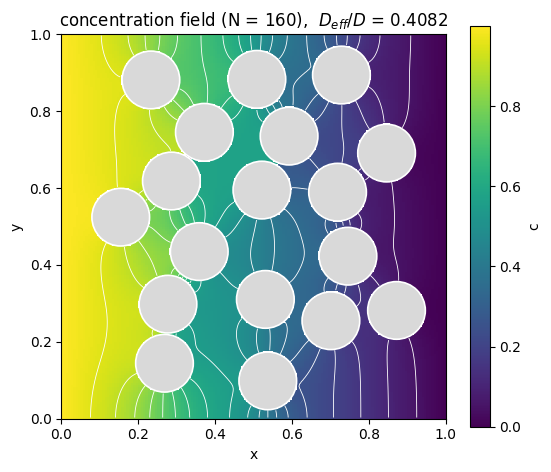

D_eff/D    = 0.4082
imbalance  = 1.26e-02


In [4]:
ref = solve_diffusion(centers, 160)
c_ref, sdf_ref, xf_ref = ref['c'], ref['sdf'], ref['x_f']
solid_ref = sdf_ref < 0
c_plot = np.ma.masked_array(c_ref, mask=solid_ref)

fig, ax = plt.subplots(figsize=(6.2, 5.2))
m = ax.pcolormesh(xf_ref[0], xf_ref[1], c_plot.T, shading='flat', cmap='viridis')
ax.contour(0.5 * (xf_ref[0][:-1] + xf_ref[0][1:]),
           0.5 * (xf_ref[1][:-1] + xf_ref[1][1:]),
           c_plot.T, levels=np.linspace(0.05, 0.95, 19), colors='w', linewidths=0.6)
for cx, cy in centers:
    ax.add_patch(Circle((cx, cy), R, facecolor='0.85', edgecolor='w', lw=1.2))
ax.set_aspect('equal')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title(f"concentration field (N = 160),  $D_{{eff}}/D$ = {ref['D_eff']:.4f}")
fig.colorbar(m, ax=ax, label='c')
plt.show()

print(f"D_eff/D    = {ref['D_eff']:.4f}")
print(f"imbalance  = {ref['imbalance']:.2e}")

## Grid-convergence study

Now we solve the **same** particle configuration on a sequence of grids obtained by
successive halving of the cell size, `N = 40, 80, 160, 320`, so the disk diameter is
resolved by 5, 10, 20 and 40 cells respectively.  We track $D_\mathrm{eff}/D$, the
inflow/outflow imbalance, and the number of crossings whose one-sided reconstruction had
to drop below second order (a marker of under-resolution -- pervasive at the coarsest
grid, gone once the disks are comfortably resolved).

In [5]:
grids = [40, 80, 160, 320]
results = {N: solve_diffusion(centers, N) for N in grids}

print(f'{"N":>5} {"h=L/N":>9} {"diam/h":>7} {"D_eff/D":>10} '
      f'{"imbalance":>11} {"crossings":>10} {"deg<2":>7} {"iso":>5}')
for N in grids:
    r = results[N]
    print(f'{N:5d} {L / N:9.5f} {2 * R / (L / N):7.0f} {r["D_eff"]:10.5f} '
          f'{r["imbalance"]:11.2e} {r["n_crossings"]:10d} {r["n_lowdeg"]:7d} {r["n_isolated"]:5d}')

    N     h=L/N  diam/h    D_eff/D   imbalance  crossings   deg<2   iso
   40   0.02500       6    0.25669    1.66e+00        412     412     4
   80   0.01250      12    0.34699    1.46e-02        858      49     3
  160   0.00625      24    0.40823    1.26e-02       1726      36     2
  320   0.00313      48    0.42527    1.77e-03       3456      32     3


### Observed order and Richardson extrapolation

With the cell size halved between levels, a method of order $p$ reduces successive
increments of $D_\mathrm{eff}$ by a factor $2^p$.  Estimating $p$ from the last three
levels and extrapolating gives a grid-independent estimate

$$D_\mathrm{eff}^{\infty} \approx D_\mathrm{eff}^{(k)}
+ \frac{D_\mathrm{eff}^{(k)} - D_\mathrm{eff}^{(k-1)}}{2^{p} - 1}.$$

In [6]:
vals = np.array([results[N]['D_eff'] for N in grids])
diffs = np.diff(vals)
orders = np.log(np.abs(diffs[:-1] / diffs[1:])) / np.log(2.0)
p_est = orders[-1]
D_inf = vals[-1] + diffs[-1] / (2 ** p_est - 1)

print('successive increments dD_eff :', np.array2string(diffs, precision=5))
print('observed orders p            :', np.array2string(orders, precision=2))
print(f'Richardson estimate D_eff/D  : {D_inf:.5f}  (order p = {p_est:.2f})')

# Dilute (2-D Maxwell / Rayleigh) estimate for insulating cylinders
D_maxwell = (1 - area_fraction) / (1 + area_fraction)
print(f'2-D Maxwell estimate (dilute): {D_maxwell:.5f}  at phi = {area_fraction:.3f}')

successive increments dD_eff : [0.0903  0.06124 0.01704]
observed orders p            : [0.56 1.85]
Richardson estimate D_eff/D  : 0.43184  (order p = 1.85)
2-D Maxwell estimate (dilute): 0.51735  at phi = 0.318


### Convergence plot

Left: $D_\mathrm{eff}/D$ approaches the Richardson limit as the grid is refined.  Right:
the error $|D_\mathrm{eff}(N) - D_\mathrm{eff}^{\infty}|$ against the cell size on a
log-log scale, with a second-order reference slope.  The immersed-boundary Neumann
treatment is second-order accurate, so the derived $D_\mathrm{eff}$ inherits close to
second-order convergence once the disks are resolved.

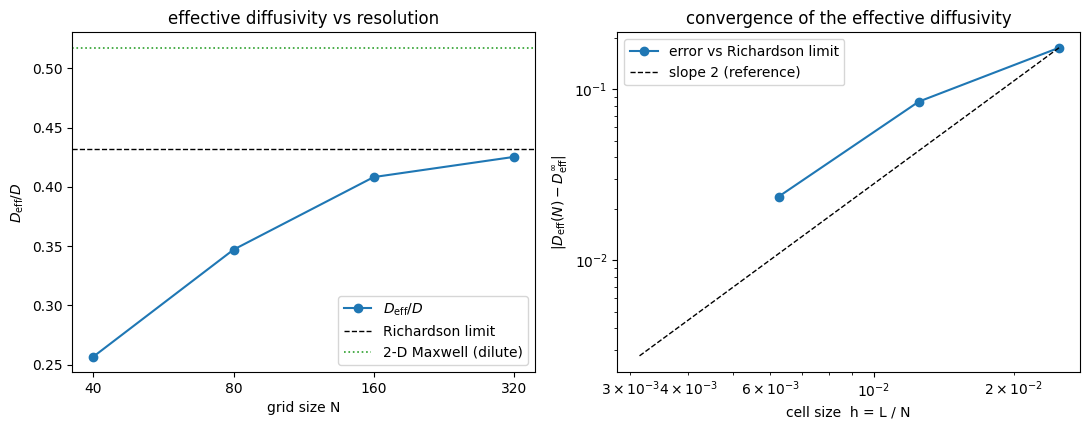

In [7]:
h = np.array([L / N for N in grids])
err = np.abs(vals - D_inf)

fig, axs = plt.subplots(1, 2, figsize=(11, 4.4))

axs[0].plot(grids, vals, 'o-', label=r'$D_\mathrm{eff}/D$')
axs[0].axhline(D_inf, color='k', ls='--', lw=1, label='Richardson limit')
axs[0].axhline(D_maxwell, color='tab:green', ls=':', lw=1.2, label='2-D Maxwell (dilute)')
axs[0].set_xscale('log', base=2)
axs[0].set_xticks(grids); axs[0].set_xticklabels(grids)
axs[0].set_xlabel('grid size N'); axs[0].set_ylabel(r'$D_\mathrm{eff}/D$')
axs[0].set_title('effective diffusivity vs resolution')
axs[0].legend()

axs[1].loglog(h[:-1], err[:-1], 'o-', label='error vs Richardson limit')
c2 = err[0] / h[0] ** 2
axs[1].loglog(h, c2 * h ** 2, 'k--', lw=1, label=r'slope 2 (reference)')
axs[1].set_xlabel('cell size  h = L / N'); axs[1].set_ylabel(r'$|D_\mathrm{eff}(N)-D_\mathrm{eff}^\infty|$')
axs[1].set_title('convergence of the effective diffusivity')
axs[1].legend()

plt.tight_layout()
plt.show()

## Summary

* A **Monte-Carlo rejection sampler** placed non-overlapping impermeable disks, clear of
  the side walls and at least one coarse cell from the inlet/outlet; the configuration is
  fixed in physical space and reused on every grid.
* The transport problem is the impermeable-particle case of the immersed boundary method:
  **homogeneous Neumann** ($\partial c/\partial n = 0$) on the fluid side of each disk
  via `construct_ibm_boundary_values`, and a **zero Dirichlet** value inside.
* The **effective diffusivity** $D_\mathrm{eff} = \bar J / (\Delta c / L)$ was obtained
  from the boundary throughput; inflow and outflow agree to a tolerance that tightens
  under refinement.
* A **grid-convergence study** (diameter resolved by 5 -> 40 cells) shows
  $D_\mathrm{eff}/D$ converging at close to second order to a Richardson limit that
  agrees with the dilute 2-D Maxwell estimate $(1-\phi)/(1+\phi)$ for insulating
  cylinders.